In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from matplotlib.ticker import FixedLocator

files = {
    'Native': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/native/summary_final.csv',
    #'Native_NB': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/native_NB_on/summary_final.csv',
    'Native_interleave': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/native_interleave/summary_final.csv',
    'SEV': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/sev/summary_final.csv',
    #'SEV_NB': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/sev_NB_on/summary_final.csv',
    'SEV_interleave': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/sev_interleave/summary_final.csv'
}
#csv header:
#Matrix,Cores,Run,Iterations,Intern_Runtime,Intern_Gflops,Perf_DurationTime,Perf_Insn,Perf_Cycl,Perf_CacheMisses,Perf_dTLBLoadMisses

matrix_path = '../../matrices/spmv_synth/'

def get_mb(row):
    r_str = str(row['Randomness']).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(row['N'])}.bin")
    return os.path.getsize(f_path) / (1024**2) if os.path.exists(f_path) else None

def get_n(f):
    m = re.search(r'N(\d+)', f)
    return int(m.group(1)) if m else 0

def get_rand(f):
    m = re.search(r'(\d)-(\d)', f)
    return float(f"{m.group(1)}.{m.group(2)}") if m else 0.0

def load_and_process(label, path):
    df = pd.read_csv(path)
    df['Mode'] = label
    df['N'] = df['Matrix'].apply(get_n)
    df['Randomness'] = df['Matrix'].apply(get_rand)
    df['MB'] = df.apply(get_mb, axis=1).round().astype('Int64')
    return df

df_list = [load_and_process(l, p) for l, p in files.items()]
df_raw = pd.concat([d for d in df_list if d is not None])
df_raw["CPI"] = df_raw["Perf_Cycl"] / df_raw["Perf_Insn"]
df_raw["IOTime"] = df_raw["Perf_DurationTime"] - df_raw["Intern_Runtime"]

group_cols = ['Mode', 'Cores', 'MB', 'Randomness']
metrics = ['Intern_Runtime', 'Intern_Gflops', 'Perf_DurationTime', 'Perf_Insn', 'Perf_Cycl', 'Perf_CacheMisses', 'Perf_dTLBLoadMisses', 'CPI', 'IOTime']

df = df_raw.groupby(group_cols)[metrics].median().reset_index()
df['Intern_Runtime_CV'] = (df_raw.groupby(group_cols)['Intern_Runtime'].std().values / df['Intern_Runtime']) * 100

In [44]:
pivot = df.pivot_table(
    index=['Cores', 'MB', 'Randomness'], 
    columns='Mode', 
    values=metrics
)
pivot.columns = [f'{metric}_{mode}' for metric, mode in pivot.columns]
pivot.reset_index(inplace=True)

for m in metrics:
    #pivot[f'Delta_Native_Native_NB_{m}'] = (pivot[f'{m}_Native_NB'] / pivot[f'{m}_Native'] - 1) * 100 #Difference of Native NB compared to Native
    #pivot[f'Delta_SEV_SEV_NB_{m}'] = (pivot[f'{m}_SEV_NB'] / pivot[f'{m}_SEV'] - 1) * 100 #Difference of SEV NB compared to SEV
    #pivot[f'Delta_Native_NB_SEV_NB_{m}'] = (pivot[f'{m}_SEV_NB'] / pivot[f'{m}_Native_NB'] - 1) * 100 #Difference of SEV NB compared to Native NB
    pivot[f'Delta_Native_SEV_{m}'] = (pivot[f'{m}_SEV'] / pivot[f'{m}_Native'] - 1) * 100 #Difference of SEV compared to Native
    pivot[f'Delta_Native_il_SEV_il_{m}'] = (pivot[f'{m}_SEV_interleave'] / pivot[f'{m}_Native_interleave'] - 1) * 100 #Difference of SEV interleave compared to Native interleave
    pivot[f'Delta_Native_Native_il_{m}'] = (pivot[f'{m}_Native_interleave'] / pivot[f'{m}_Native'] - 1) * 100 #Difference of Native interleave compared to Native
    pivot[f'Delta_SEV_SEV_il_{m}'] = (pivot[f'{m}_SEV_interleave'] / pivot[f'{m}_SEV'] - 1) * 100 #Difference of SEV interleave compared to SEV

In [ ]:
# Sanity-Check: Sind Perf_Insn pro gleicher Config (Cores, MB, Randomness) über alle Varianten ähnlich?

insn_cols = [c for c in pivot.columns if c.startswith("Perf_Insn_")]
cfg_cols = ["Cores", "MB", "Randomness"]

if len(insn_cols) < 2:
	print("Nicht genug Perf_Insn-Spalten für einen Vergleich gefunden.")
else:
	insn_check = pivot[cfg_cols + insn_cols].copy()

	# Streuungsmetriken über Varianten je gleicher Config
	insn_check["Perf_Insn_mean"] = insn_check[insn_cols].mean(axis=1)
	insn_check["Perf_Insn_std"] = insn_check[insn_cols].std(axis=1)
	insn_check["Perf_Insn_cv_pct"] = (insn_check["Perf_Insn_std"] / insn_check["Perf_Insn_mean"]) * 100
	insn_check["Perf_Insn_min"] = insn_check[insn_cols].min(axis=1)
	insn_check["Perf_Insn_max"] = insn_check[insn_cols].max(axis=1)
	insn_check["Perf_Insn_rel_range_pct"] = (
		(insn_check["Perf_Insn_max"] - insn_check["Perf_Insn_min"]) / insn_check["Perf_Insn_mean"]
	) * 100
	insn_check["Perf_Insn_max_over_min"] = insn_check["Perf_Insn_max"] / insn_check["Perf_Insn_min"]

	print("Verwendete Spalten:", insn_cols)
	print("\nZusammenfassung (CV% und relative Range%):")
	print(insn_check[["Perf_Insn_cv_pct", "Perf_Insn_rel_range_pct"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

	# Toleranz für "ähnlich" (anpassbar)
	tol_pct = 1.0
	ok_mask = insn_check["Perf_Insn_rel_range_pct"] <= tol_pct

	print(f"\nConfigs gesamt: {len(insn_check)}")
	print(f"Configs innerhalb ±{tol_pct:.1f}% rel. Range: {ok_mask.sum()} ({ok_mask.mean()*100:.1f}%)")
	print(f"Configs außerhalb ±{tol_pct:.1f}% rel. Range: {(~ok_mask).sum()} ({(~ok_mask).mean()*100:.1f}%)")

	print("\nTop-10 auffällige Configs (größte rel. Range in Perf_Insn):")
	display(
		insn_check.sort_values("Perf_Insn_rel_range_pct", ascending=False)
		.head(10)[cfg_cols + ["Perf_Insn_rel_range_pct", "Perf_Insn_cv_pct"] + insn_cols]
	)

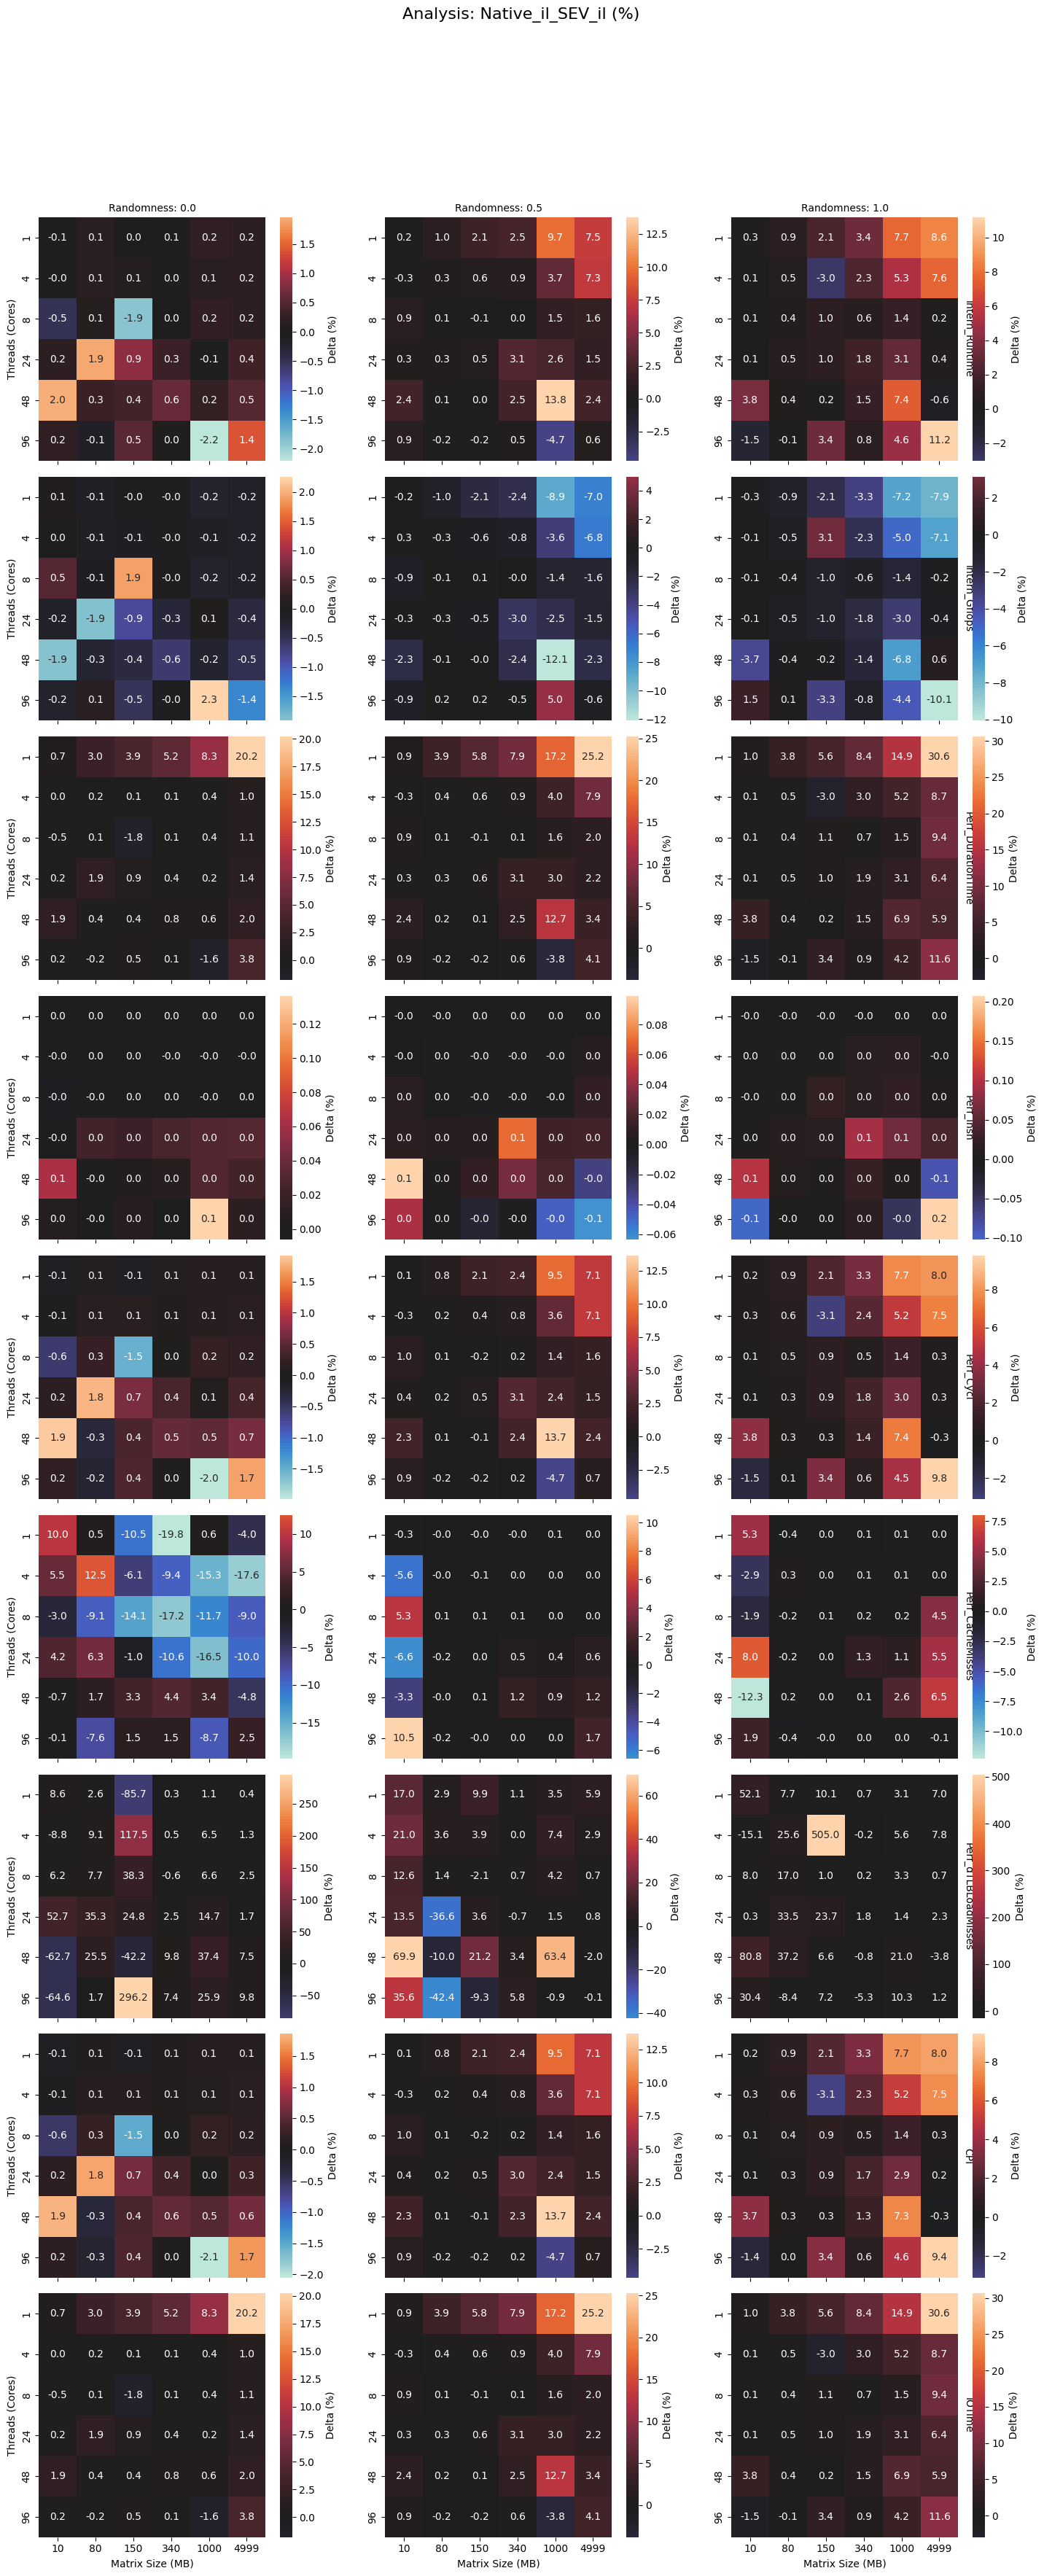

In [48]:
def plot_delta_heatmaps(pivot_df, comparison_type, selected_metrics=None):
    """
    comparison_type: 'Native_Native_NB', 'SEV_SEV_NB', 'Native_SEV' or 'Native_NB_SEV_NB'
    selected_metrics: List of metrics
    """

    prefix = f"Delta_{comparison_type}"
    relevant_cols = [c for c in pivot_df.columns if c.startswith(prefix)]
    
    if selected_metrics:
        relevant_cols = [c for c in relevant_cols if any(m in c for m in selected_metrics)]
    
    if not relevant_cols:
        print(f"Keine Daten für den Vergleich '{comparison_type}' gefunden!")
        return

    df_long = pivot_df.melt(
        id_vars=['Cores', 'MB', 'Randomness'], 
        value_vars=relevant_cols, 
        var_name='Metric', 
        value_name='Delta_Value'
    )

    df_long['Metric_Clean'] = df_long['Metric'].str.replace(f"{prefix}_", "")

    g = sns.FacetGrid(
        df_long, 
        row="Metric_Clean", 
        col="Randomness", 
        height=4, 
        aspect=1.2, 
        margin_titles=True,
        sharex=True, 
        sharey=False 
    )

    def draw_heatmap(data, **kwargs):
        d = data.pivot(index='Cores', columns='MB', values='Delta_Value').sort_index(axis=1)
        sns.heatmap(
            d, annot=True, fmt=".1f", center=0, 
            cbar_kws={'label': 'Delta (%)'}, **kwargs
        )

    g.map_dataframe(draw_heatmap)
    g.set_axis_labels("Matrix Size (MB)", "Threads (Cores)")
    g.set_titles(col_template="Randomness: {col_name}", row_template="{row_name}")
    
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f"Analysis: {comparison_type} (%)", fontsize=16)
    plt.show()

plot_delta_heatmaps(pivot, 'Native_il_SEV_il', selected_metrics=metrics)

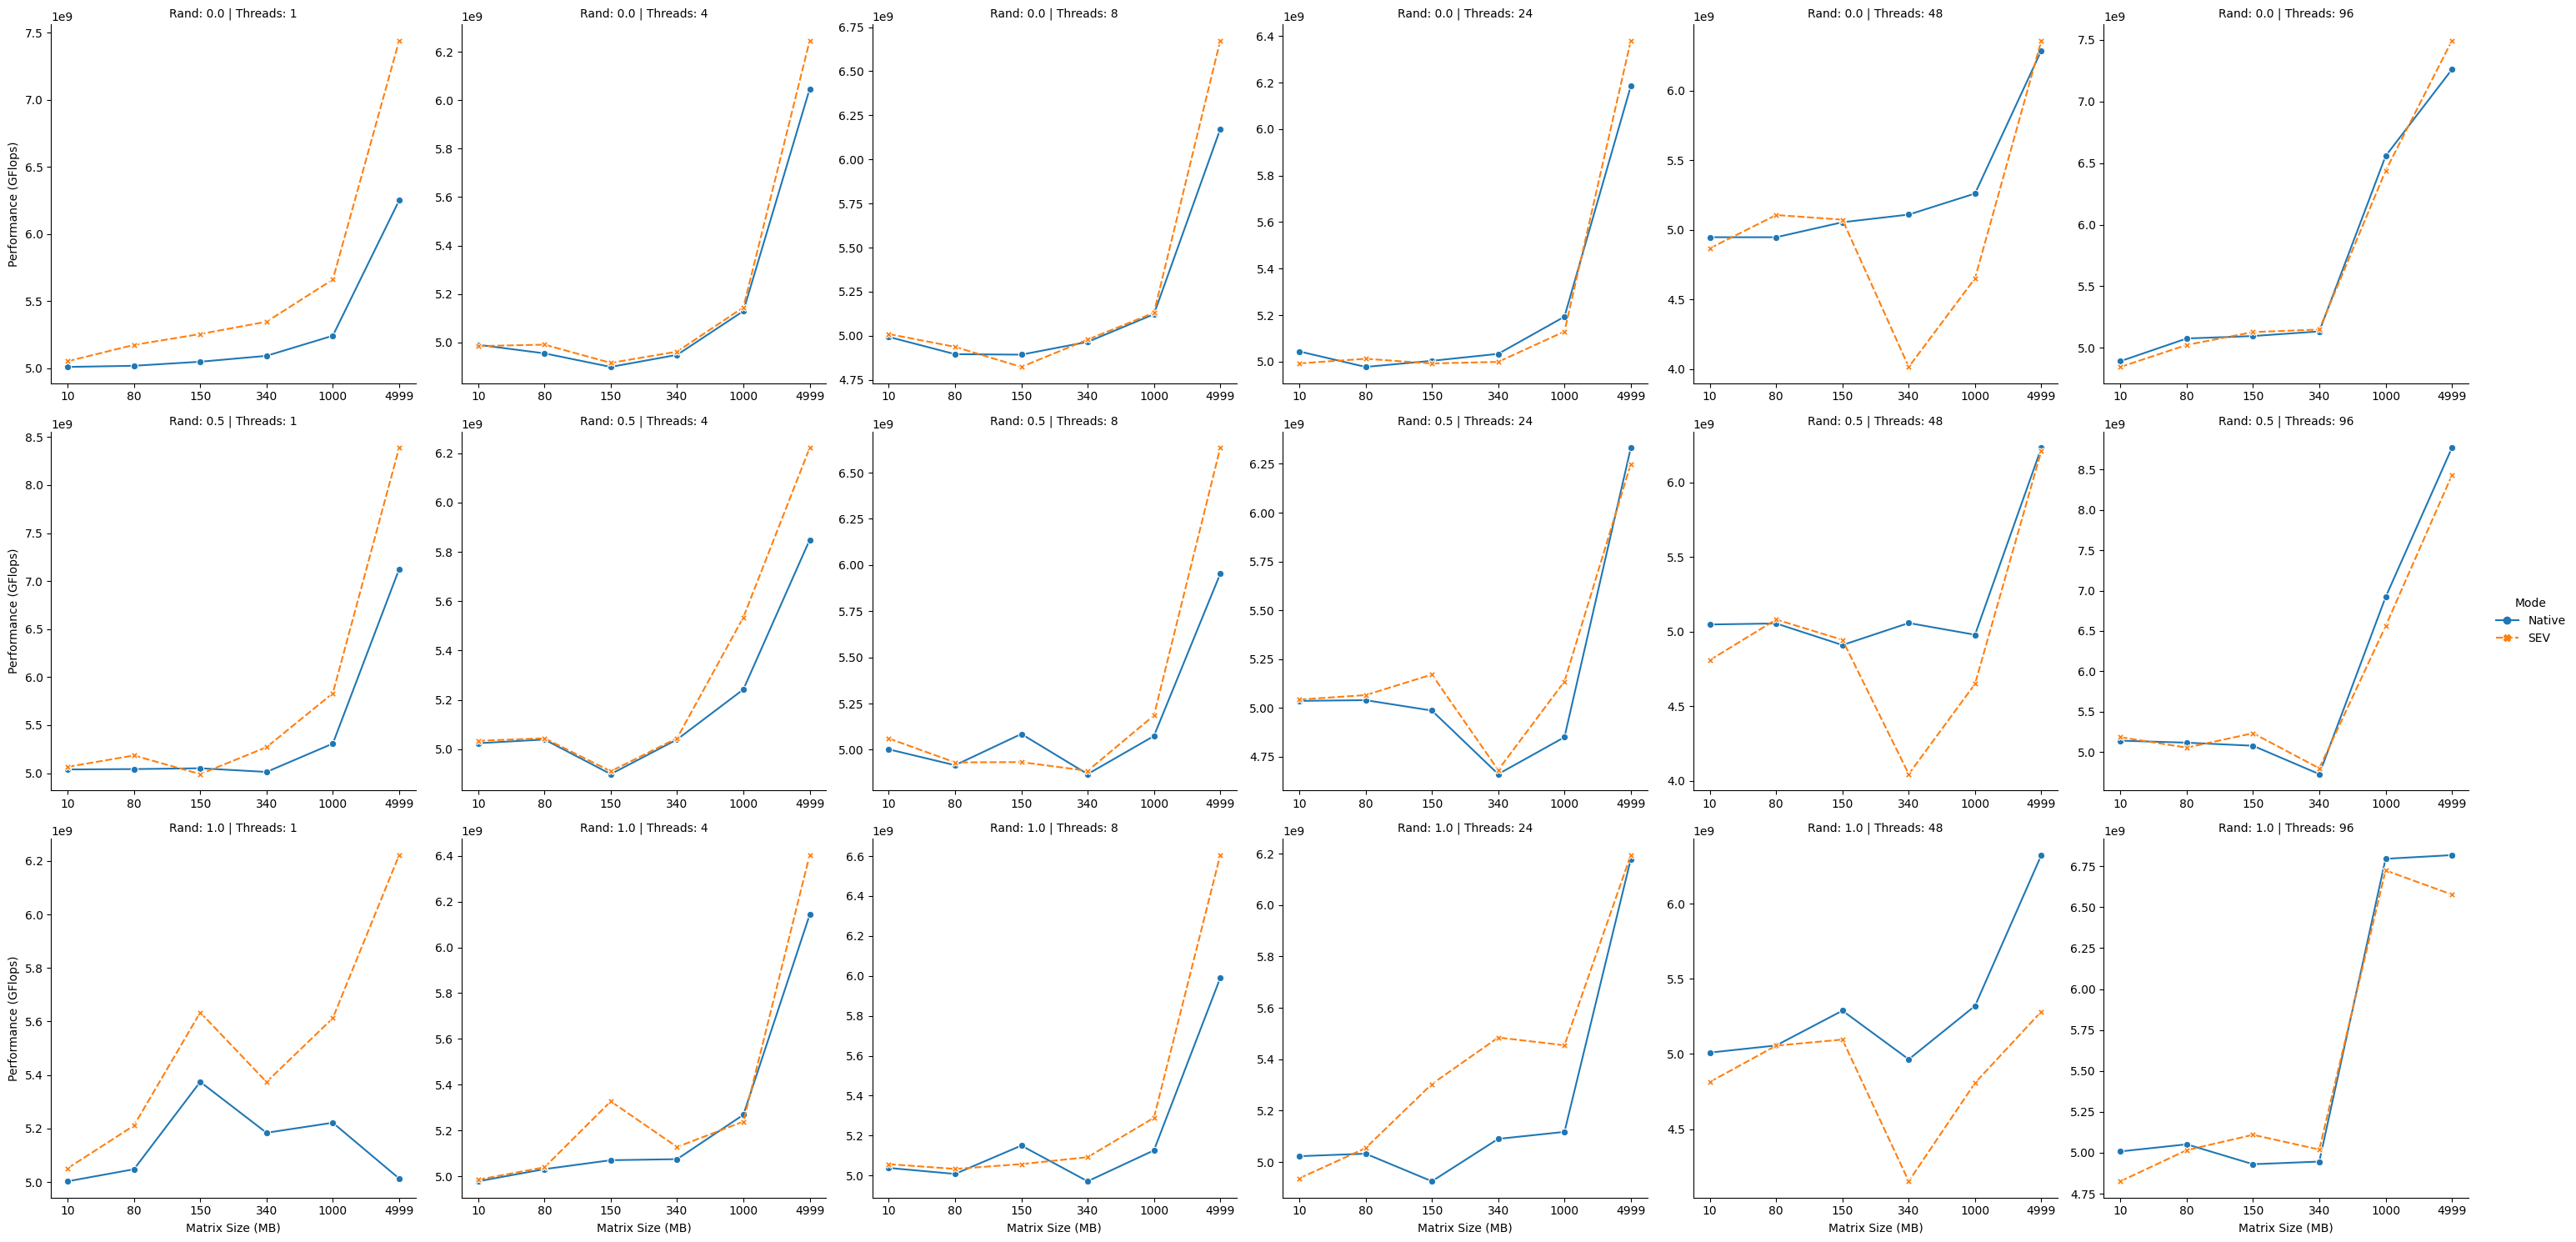

In [21]:
# Daten vorbereiten
df_sorted = df.sort_values(['Randomness', 'MB'])
df_plot = df_sorted.assign(MB_str=df_sorted['MB'].astype(str))

g = sns.relplot(
    data=df_plot,
    x='MB_str',
    y='IOTime',
    hue='Mode',        
    style='Mode',      
    col='Cores',       
    row='Randomness', 
    kind='line',
    markers=True,
    facet_kws={'sharex': False, 'sharey': False}
)

g.set_axis_labels("Matrix Size (MB)", "Performance (GFlops)")
g.set_titles(col_template="Threads: {col_name}", row_template="Rand: {row_name}")